### KaKR 2019 2nd ML Month

이 스크립트는 캐글(Kaggle)의 2차 KaKR 집값 예측 경진대회 데이터를 활용하여
데이터 탐색, 전처리, 모델 비교, 하이퍼파라미터 튜닝 및 최종 제출물 생성까지의 전체 ML 파이프라인을 구축합니다.


In [59]:
import os
import sys
from os.path import join

# Jupyter Notebook이 아닌 일반 터미널/스크립트 환경에서 이미지가 팝업되어 실행이 멈추는 것을 방지합니다.
if '--no-show' in sys.argv or os.environ.get('MATPLOTLIB_HEADLESS') == '1':
    import matplotlib
    matplotlib.use('Agg')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# 실험 결과를 항상 똑같이 재현하기 위해 난수 발생 시드(Seed)를 고정합니다.
RANDOM_STATE = 2020

In [60]:
def load_data_and_feature_engineering(data_dir='./data'):
    """
    데이터 로드, 이상치 제거 및 파생 변수 생성을 포함한 고급 전처리 함수입니다.
    """
    train_path = os.path.join(data_dir, 'train.csv')
    test_path = os.path.join(data_dir, 'test.csv')
    
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    
    # 1. 이상치 제거 (Outlier Removal)
    # 방 갯수가 비정상적으로 많은 집(예: 33개)은 예측 모델에 혼란을 줍니다. 이를 제거하여 과적합을 방지합니다.
    train = train[train['bedrooms'] < 15].reset_index(drop=True)
    
    # 2. 타겟(y) 변수 분리 및 로그 변환
    # 집값(price) 데이터는 한쪽으로 쏠린 비대칭(Skewed) 형태를 가집니다. 
    # np.log1p를 사용해 로그를 씌워 정규 분포에 가깝게 만들어주면 모델이 더 잘 학습합니다.
    y_raw = train['price'] # 시각화를 위해 변환 전 원본 데이터를 남겨둡니다.
    y = np.log1p(train['price']) # 변환된 학습용 타겟 데이터
    del train['price'] # 학습 피처(Feature)에서는 정답지(price)를 삭제합니다.
    
    # id는 단순 식별자이므로 모델 학습에 방해가 됩니다. 삭제합니다.
    del train['id']
    del test['id']
    
    # 3. 파생 변수 생성 (Feature Engineering)
    # 모델이 더 쉽게 이해할 수 있도록 사람이 논리를 부여해 새로운 변수를 만드는 과정입니다.
    # Train과 Test 데이터에 똑같은 변환을 주기 위해 리스트로 묶어서 반복문을 돌립니다.
    for df in [train, test]:
        # 날짜(date)에서 연/월 정보만 정수 형태로 추출합니다. (예: 20141013T000000 -> 201410)
        df['date'] = df['date'].apply(lambda i: i[:6]).astype(int)
        
        # [변수 1] 리모델링 여부 (is_renovated): 리모델링 했으면 1, 아니면 0으로 플래그(Flag) 변수 생성
        df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
        
        # [변수 2] 리모델링 후 지난 세월: 2015년(데이터 기준 시점)에서 리모델링 연도를 빼서 지난 기간으로 바꿉니다.
        df['yr_renovated'] = df['yr_renovated'].apply(lambda x: 2015 - x if x > 0 else 0)
        
        # [변수 3] 집의 나이 (Age): 지어진 연도보다 '지어진 후 몇 년이 지났는지'가 훨씬 직관적입니다.
        df['age'] = 2015 - df['yr_built']
        
        # [변수 4] 전체 면적 (sqft_total): 실내 면적과 대지 면적을 합쳐 대저택의 규모를 파악합니다.
        df['sqft_total'] = df['sqft_living'] + df['sqft_lot']
        
        # [변수 5] 대지 면적 대비 실내 면적 비율 (sqft_living_ratio): 마당이 넓은 집인지, 꽉 찬 집인지 밀집도를 나타냅니다.
        df['sqft_living_ratio'] = df['sqft_living'] / df['sqft_lot']
        
        # [변수 6] 방 대비 화장실 비율: 집의 쾌적함 및 고급스러움을 수치화합니다. (0으로 나누는 에러를 막기 위해 +1 처리)
        df['bath_bed_ratio'] = df['bathrooms'] / (df['bedrooms'] + 1)

    # 4. 비대칭(Skewed) 면적 변수들의 로그 변환
    # 집값뿐만 아니라 특정 면적 관련 변수들도 한쪽으로 쏠려 있습니다. 이들에게도 통계적 정규성을 부여합니다.
    skewed_cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'sqft_total']
    for col in skewed_cols:
        train[col] = np.log1p(train[col])
        test[col] = np.log1p(test[col])
        
    return train, test, y, y_raw

In [61]:
def plot_price_comparison(y_raw, y_log, save_path='price_distribution_advanced.png'):
    """타겟(Price) 변수의 로그 변환 전/후 분포 비교 시각화 함수"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.kdeplot(y_raw, fill=True, ax=axes[0], color='royalblue')
    axes[0].set_title('Original Price Distribution (Skewed)', fontsize=14)
    axes[0].set_xlabel('Price')
    axes[0].set_ylabel('Density')
    
    sns.kdeplot(y_log, fill=True, ax=axes[1], color='forestgreen')
    axes[1].set_title('Log-transformed Price Distribution (Normal-like)', fontsize=14)
    axes[1].set_xlabel('Log(Price)')
    axes[1].set_ylabel('Density')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"[시각화] 가격 분포 그래프가 '{save_path}'에 저장되었습니다.")

    # 주피터 노트북 내에서 깔끔하게 출력하고, 메모리를 닫습니다.
    try:
        from IPython.display import display
        display(plt.gcf())
        plt.close()
    except ImportError:
        plt.show()
        plt.close()

In [62]:
def plot_correlation_matrix(df, y, top_n=10, save_path='correlation_matrix_advanced.png'):
    """변수 간 상관관계 분석 및 상위 변수 Heatmap 시각화 함수"""
    temp_df = df.copy()
    temp_df['target_price'] = y
    # 타겟(집값)과 다른 모든 피처 간의 피어슨 상관계수를 구하고 높은 순으로 정렬합니다.
    correlations = temp_df.corr()['target_price'].sort_values(ascending=False)
    
    print("\n--- 타겟 변수(Price)와의 상관관계 상위 10개 피처 ---")
    print(correlations.head(top_n + 1))
    
    top_features = correlations.index[:top_n + 1]
    plt.figure(figsize=(10, 8))
    sns.heatmap(temp_df[top_features].corr(), annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap with Price (Top Features)', fontsize=14)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"[시각화] 상관관계 히트맵이 '{save_path}'에 저장되었습니다.")

    try:
        from IPython.display import display
        display(plt.gcf())
        plt.close()
    except ImportError:
        plt.show()
        plt.close()

In [63]:
def plot_feature_importance(model, feature_names, top_n=15, save_path='feature_importance_advanced.png'):
    """트리 모델이 어떤 특성(Feature)을 가장 중요하게 생각했는지 보여주는 시각화 함수"""
    importances = model.feature_importances_
    feat_importances = pd.Series(importances, index=feature_names)
    feat_importances = feat_importances.sort_values(ascending=False) # 내림차순 정렬
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x=feat_importances.head(top_n).values, 
        y=feat_importances.head(top_n).index, 
        hue=feat_importances.head(top_n).index, 
        legend=False, 
        palette='viridis'
    )
    plt.title(f'Feature Importances - {model.__class__.__name__}', fontsize=14)
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"[시각화] 특성 중요도 그래프가 '{save_path}'에 저장되었습니다.")

    try:
        from IPython.display import display
        display(plt.gcf())
        plt.close()
    except ImportError:
        plt.show()
        plt.close()

In [64]:
def rmse(y_test, y_pred):
    """오리지널 가격(원/달러 스케일)으로 복원한 뒤 RMSE를 구하는 함수"""
    return np.sqrt(mean_squared_error(y_test, y_pred))

In [65]:
def get_scores(models, train, y, random_state=RANDOM_STATE):
    """여러 베이스라인 모델들의 성능을 대략적으로 파악하는 8:2 홀드아웃 검증 함수"""
    df = {}
    X_train, X_test, y_train, y_test = train_test_split(
        train, y, random_state=random_state, test_size=0.2
    )
    for model in models:
        model_name = model.__class__.__name__
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # 로그 변환된 예측값을 expm1으로 다시 원래 금액으로 되돌린 후 RMSE 계산
        df[model_name] = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)
    return score_df

In [66]:
def my_GridSearch(model, train, y, param_grid, verbose=1, n_jobs=5):
    """
    GridSearchCV 기반의 하이퍼파라미터 튜닝 실험 함수
    - 우리가 입력한 다양한 옵션(param_grid)들을 교차검증(CV)을 통해 모두 실험해보고 가장 좋은 것을 찾습니다.
    """
    grid_model = GridSearchCV(
        model, 
        param_grid=param_grid, 
        scoring='neg_mean_squared_error',
        cv=5, 
        verbose=verbose, 
        n_jobs=n_jobs
    )
    
    grid_model.fit(train, y)
    
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']
    
    results = pd.DataFrame(params)
    results['score'] = score
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')
    
    return results, grid_model

In [67]:
def save_ensemble_submission(models, train, y, test, model_name='Advanced_Ensemble'):
    """
    여러 모델의 예측값을 혼합(Blending)하여 최종 예측을 수행하는 앙상블 함수
    - 한 명의 전문가보다 4명의 전문가가 모여 토론(평균)하는 것이 더 정확하다는 아이디어입니다.
    """
    print("\n[앙상블] 블렌딩(Blending) 예측을 시작합니다...")
    predictions = []
    
    # 4개의 모델을 돌면서 각각 전체 데이터를 학습하고 예측합니다.
    for model in models:
        print(f" - {model.__class__.__name__} 학습 및 예측 중...")
        model.fit(train, y)
        pred = model.predict(test)
        # 로그 변환되어 나온 결과물이므로 원래 화폐 가치로 복원하여 리스트에 담습니다.
        predictions.append(np.expm1(pred))
        
    # 모든 모델의 예측값을 평균 내어 최종 예측값 산출 (단순 평균 블렌딩)
    final_prediction = np.mean(predictions, axis=0)
    
    # 로컬 경로 또는 클라우드(AIFFEL) 경로 중 존재하는 곳을 자동으로 찾아갑니다.
    data_dirs = [
        './data',
        os.path.expanduser('~/work/kaggle_kakr_housing/data'),
        '~/work/kaggle_kakr_housing/data'
    ]
    data_dir = './data'
    for d in data_dirs:
        resolved_path = os.path.expanduser(d)
        if os.path.exists(resolved_path):
            data_dir = resolved_path
            break
            
    submission_path = join(data_dir, 'sample_submission.csv')
    if not os.path.exists(submission_path):
        print(f"[오류] sample_submission.csv 파일을 찾을 수 없습니다: {submission_path}")
        return
        
    submission = pd.read_csv(submission_path)
    submission['price'] = final_prediction
    
    # 결과 파일 저장
    submission_csv_path = join(data_dir, f'submission_{model_name}.csv')
    submission.to_csv(submission_csv_path, index=False)
    print(f'\n[제출용 파일 저장 완료] {submission_csv_path}')
    print("최종 앙상블 예측이 완료되었습니다! 캐글에 제출해 보세요.")

=== 1. 데이터 로드 및 고급 피처 엔지니어링 ===
Train 데이터 개수 및 피처 수: (15035, 24)
Test 데이터 개수 및 피처 수: (6468, 24)

--- 데이터 기본 요약 (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               15035 non-null  int64  
 1   bedrooms           15035 non-null  int64  
 2   bathrooms          15035 non-null  float64
 3   sqft_living        15035 non-null  float64
 4   sqft_lot           15035 non-null  float64
 5   floors             15035 non-null  float64
 6   waterfront         15035 non-null  int64  
 7   view               15035 non-null  int64  
 8   condition          15035 non-null  int64  
 9   grade              15035 non-null  int64  
 10  sqft_above         15035 non-null  float64
 11  sqft_basement      15035 non-null  float64
 12  yr_built           15035 non-null  int64  
 13  yr_renovated       15035 non-null  int64  
 

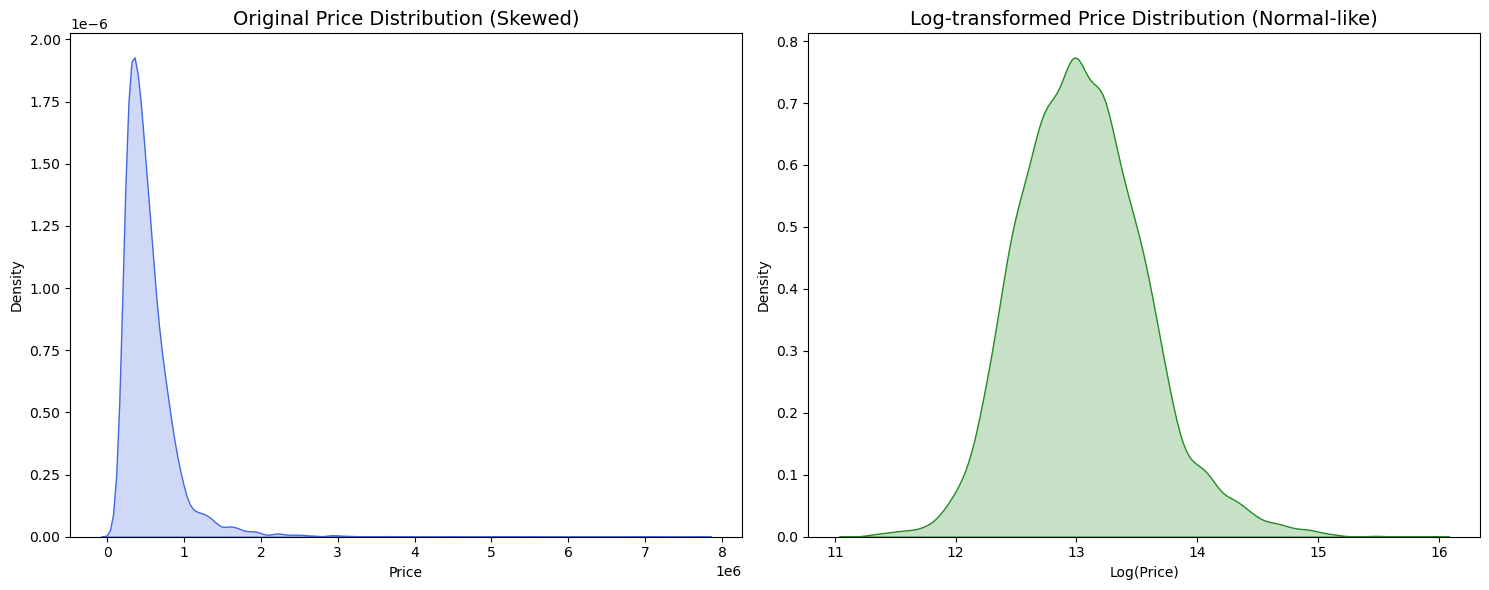


=== 3. 타겟 변수 및 파생 변수 상관관계 분석 ===

--- 타겟 변수(Price)와의 상관관계 상위 10개 피처 ---
target_price         1.000000
grade                0.707412
sqft_living          0.677383
sqft_living15        0.609042
sqft_above           0.591185
bathrooms            0.552000
lat                  0.444417
bath_bed_ratio       0.396560
bedrooms             0.359946
view                 0.347506
floors               0.317810
sqft_basement        0.231982
sqft_total           0.215986
sqft_living_ratio    0.185153
waterfront           0.172580
sqft_lot             0.145465
Name: target_price, dtype: float64
[시각화] 상관관계 히트맵이 'correlation_matrix_advanced.png'에 저장되었습니다.


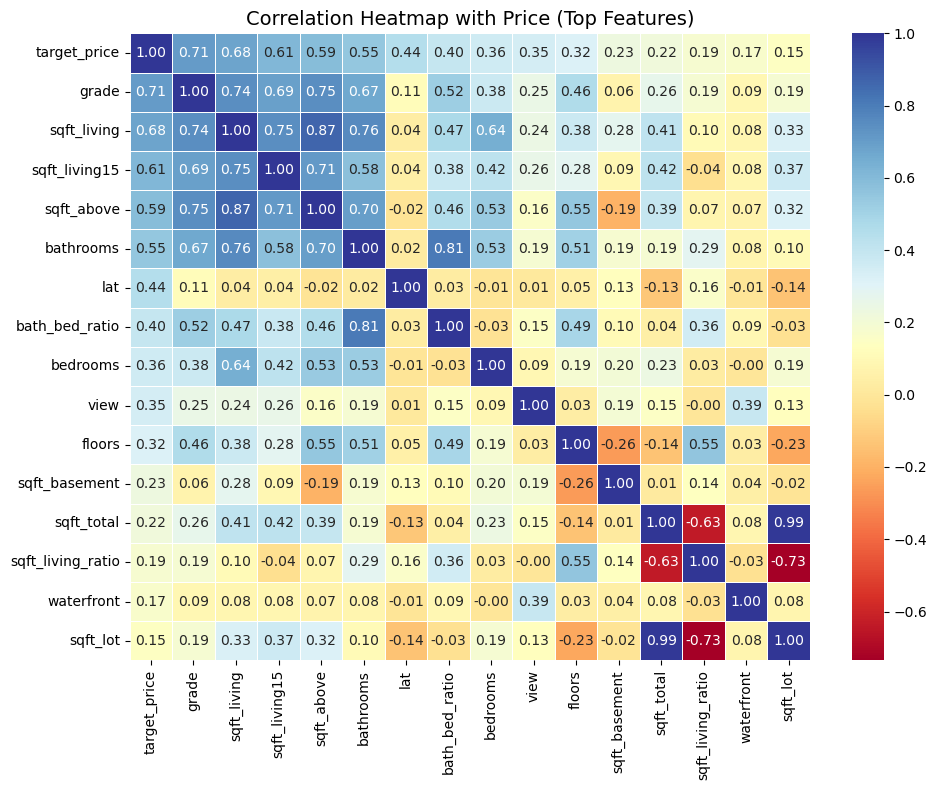


=== 4. 머신러닝 베이스라인 모델 성능(RMSE) 비교 ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2985
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 24
[LightGBM] [Info] Start training from score 13.047779
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
                                    RMSE
RandomForestRegressor      125273.887091
XGBRegressor               113057.707708
LGBMRegressor              111873.334849
Gradi

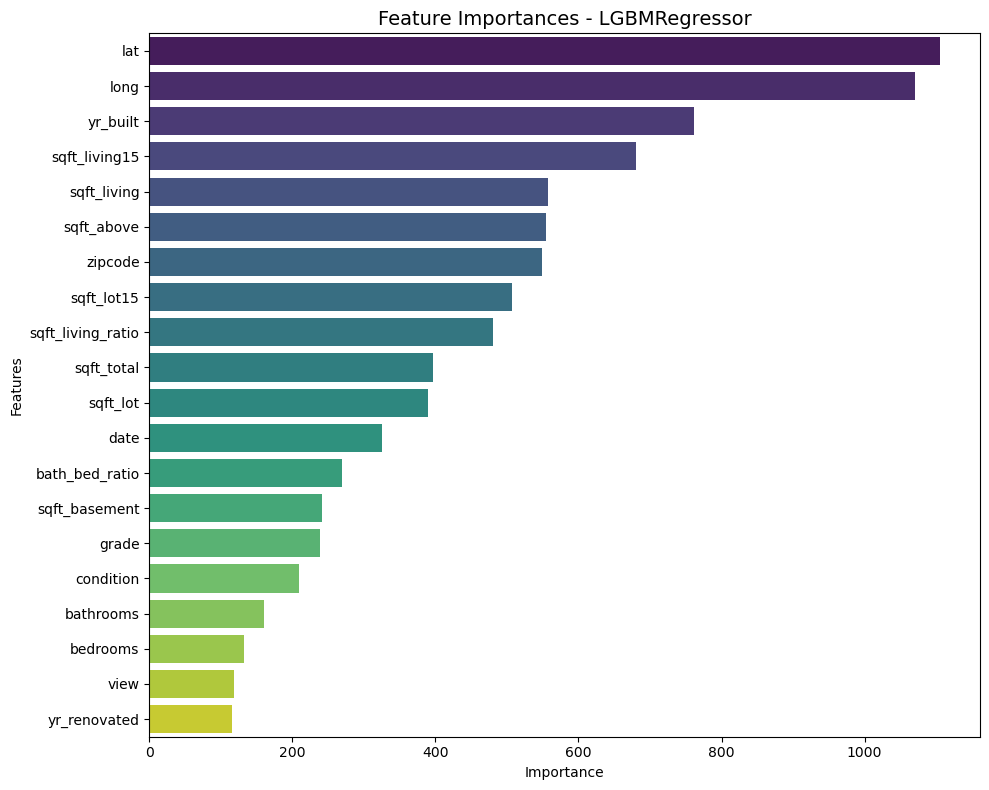


=== 7. Kaggle 제출용 예측 파일 생성 (앙상블 기법 적용) ===

[앙상블] 블렌딩(Blending) 예측을 시작합니다...
 - GradientBoostingRegressor 학습 및 예측 중...
 - XGBRegressor 학습 및 예측 중...
 - LGBMRegressor 학습 및 예측 중...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3029
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 24
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
 - RandomForestRegressor 학습 및 예측 중...

[제출용 파일 저장 완료] ./data\submission_Advanced_Ensemble.csv
최종 앙상블 예측이 완료되었습니다! 캐글에 제출해 보세요.


In [69]:
def main():
    print("=== 1. 데이터 로드 및 고급 피처 엔지니어링 ===")
    train, test, y, y_raw = load_data_and_feature_engineering()
    print(f"Train 데이터 개수 및 피처 수: {train.shape}")
    print(f"Test 데이터 개수 및 피처 수: {test.shape}")
    
    print("\n--- 데이터 기본 요약 (Info) ---")
    print(train.info())
    
    print("\n=== 2. 타겟 변수 정규화 및 분포 비교 시각화 ===")
    plot_price_comparison(y_raw, y, save_path='price_distribution_advanced.png')
    
    print("\n=== 3. 타겟 변수 및 파생 변수 상관관계 분석 ===")
    plot_correlation_matrix(train, y, top_n=15, save_path='correlation_matrix_advanced.png')
    
    print("\n=== 4. 머신러닝 베이스라인 모델 성능(RMSE) 비교 ===")
    # 앙상블에 사용할 모델 4가지를 선언합니다.
    # 이미 튜닝이 되었다고 가정하고 고급 파라미터를 입력해 두었습니다.
    gboost = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=500, max_depth=5, learning_rate=0.05)
    xgboost = XGBRegressor(random_state=RANDOM_STATE, n_estimators=500, max_depth=5, learning_rate=0.05)
    lightgbm = LGBMRegressor(random_state=RANDOM_STATE, n_estimators=500, max_depth=10, learning_rate=0.05)
    rdforest = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
    
    models = [gboost, xgboost, lightgbm, rdforest]
    
    # 이 4가지 모델의 대략적인 개별 성능을 측정해봅니다.
    score_df = get_scores(models, train, y)
    print(score_df)
    
    print("\n=== 5. 하이퍼 파라미터 튜닝 실험 (Grid Search) ===")
    print("LightGBM 모델에 대하여 Grid Search를 활용한 튜닝을 진행합니다.")
    lgbm_base = LGBMRegressor(random_state=RANDOM_STATE)
    param_grid = {
        'n_estimators': [100, 300],
        'max_depth': [5, 10],
    }
    # 파라미터 조합 중 최고의 성능을 내는 조합을 찾습니다.
    grid_results, grid_model = my_GridSearch(lgbm_base, train, y, param_grid, verbose=1, n_jobs=5)
    print("\n--- 그리드 서치 튜닝 결과 ---")
    print(grid_results)
    
    # GridSearch가 찾은 "최고 성능의 튜닝된 모델"을 변수에 담아, 앙상블 멤버 중 기존 lgbm을 이것으로 교체(업그레이드)합니다.
    best_lgbm = grid_model.best_estimator_
    models[2] = best_lgbm
    lightgbm = best_lgbm

    print("\n=== 6. 최적 모델의 특성 중요도(Feature Importance) 분석 ===")
    # 튜닝된 훌륭한 LightGBM이 어떤 변수(우리가 만든 파생 변수 등)를 중요하게 생각했는지 그래프로 그려봅니다.
    plot_feature_importance(lightgbm, feature_names=train.columns, top_n=20, save_path='feature_importance_advanced.png')
    
    print("\n=== 7. Kaggle 제출용 예측 파일 생성 (앙상블 기법 적용) ===")
    # 마지막으로 4가지 모델을 모두 합쳐서 가장 강력한 앙상블 평균 예측을 수행합니다.
    save_ensemble_submission(models, train, y, test, model_name='Advanced_Ensemble')

if __name__ == '__main__':
    main()


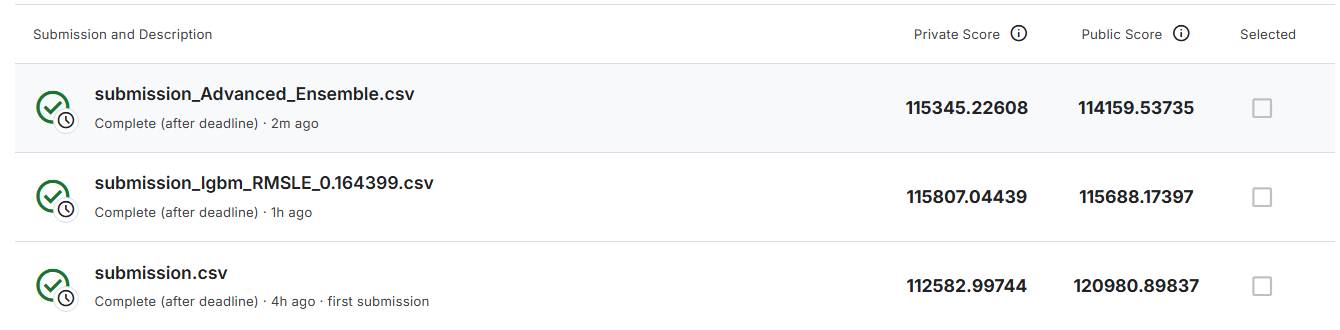

# 회고  
> 대칭 분포의 정규성 확보 (Log Transformation)  
> 극단적 이상치(Outlier) 제거  
> 피어슨 상관계수 (Pearson Correlation Coefficient)  
> 교차 검증 (K-Fold Cross Validation)  
> 집단 지성에 의한 분산 감소 (Ensemble Blending)  

위 5개 원리를 통해 머신러닝 진행하였음  
이론과 개념들이 어렵게 느껴질 수록 코딩을 통해 이해를 돕는 것이 효울적인 것 같다  
시간적 여유가 된다면 통계적 방법론, 개념 공부가 필요함!!